In [ ]:
# 1. Data overlap both between two queries and within the whole sequence
# 2. Average length of sequence
# 3. Average number of logical sessions at same time
# 4. Average number of logical sessions total

In [9]:
from load_raw_data import reconstruct_mapping
import pandas as pd
from IPython.display import display

def analyze_sequence_overlap(sequence_data):
    """
    Analyzes data overlap and unique node traversal for a query sequence.

    Args:
        sequence_data (dict): The sequence dictionary containing 'sequence' list.

    Returns:
        dict: Sequence metrics including overlap and unique source counts.
    """
    queries = sequence_data.get('sequence', [])

    cumulative_visited = set()
    previous_visited = set()
    query_metrics = []

    for index, query_obj in enumerate(queries):
        query_string = query_obj.get("queryString", "")
        topologies = query_obj.get("topologies", [])

        # Take the union of all visited nodes across repetitions for this query
        visited_in_query = set()
        for topology in topologies:
            if topology is None:
                continue

            # Extract nodes from the dictionary, discarding the dummy 'root' node
            nodes = set(topology.get("indexToNodeDict", {}).values())
            nodes.discard("root")
            visited_in_query.update(nodes)

        # Calculate sequential overlap (Q_i intersect Q_i-1)
        sequential_overlap = len(visited_in_query & previous_visited) if index > 0 else 0

        # Calculate new sources (Q_i minus cumulative previous queries)
        new_sources = len(visited_in_query - cumulative_visited)

        query_metrics.append({
            "query_index": index,
            "total_visited": len(visited_in_query),
            "overlap_with_previous": sequential_overlap,
            "new_sources": new_sources
        })

        # Update trackers
        previous_visited = visited_in_query
        cumulative_visited.update(visited_in_query)

    return {
        "total_unique_sources": len(cumulative_visited),
        "query_metrics": query_metrics
    }

def display_sequence_metrics(mapping_output: dict) -> pd.DataFrame:
    """
    Calculates overlap metrics for all sequences and displays the result as a Pandas DataFrame.

    Args:
        mapping_output (dict): The complete mapping dictionary.

    Returns:
        pd.DataFrame: The generated metrics dataframe.
    """
    rows = []

    for sequence_name, sequence_data in mapping_output.items():
        # Compute metrics using the previously defined function
        metrics = analyze_sequence_overlap(sequence_data)
        total_unique = metrics["total_unique_sources"]

        # Extract per-query metrics into flat rows
        for qm in metrics["query_metrics"]:
            rows.append({
                "Sequence": sequence_name,
                "Query Index": qm["query_index"],
                "Visited Nodes": qm["total_visited"],
                "Sequential Overlap": qm["overlap_with_previous"],
                "New Sources": qm["new_sources"],
                "Sequence Total Unique": total_unique
            })

    df = pd.DataFrame(rows)

    # Render the DataFrame natively in Jupyter
    display(df)
    return df

mapping_output = reconstruct_mapping("../data/sweep-results/run_1_baseline_2026-06-30T18-54-15-769Z/generated/out-queries",
                    "../data/sweep-results/run_1_baseline_2026-06-30T18-54-15-769Z/combinations/combination_0/output-topology-tracking")
df_metrics = display_sequence_metrics(mapping_output)

,Sequence,Query Index,Visited Nodes,Sequential Overlap,New Sources,Sequence Total Unique
0,sequence_2,0,106,0,106,8531
1,sequence_2,1,252,106,146,8531
2,sequence_2,2,106,106,0,8531
3,sequence_2,3,1080,0,1080,8531
4,sequence_2,4,5268,1080,4188,8531
...,...,...,...,...,...,...
182,sequence_4,16,18607,913,3159,51357
183,sequence_4,17,17739,3001,5538,51357
184,sequence_4,18,26974,3018,6521,51357
185,sequence_4,19,54,7,0,51357


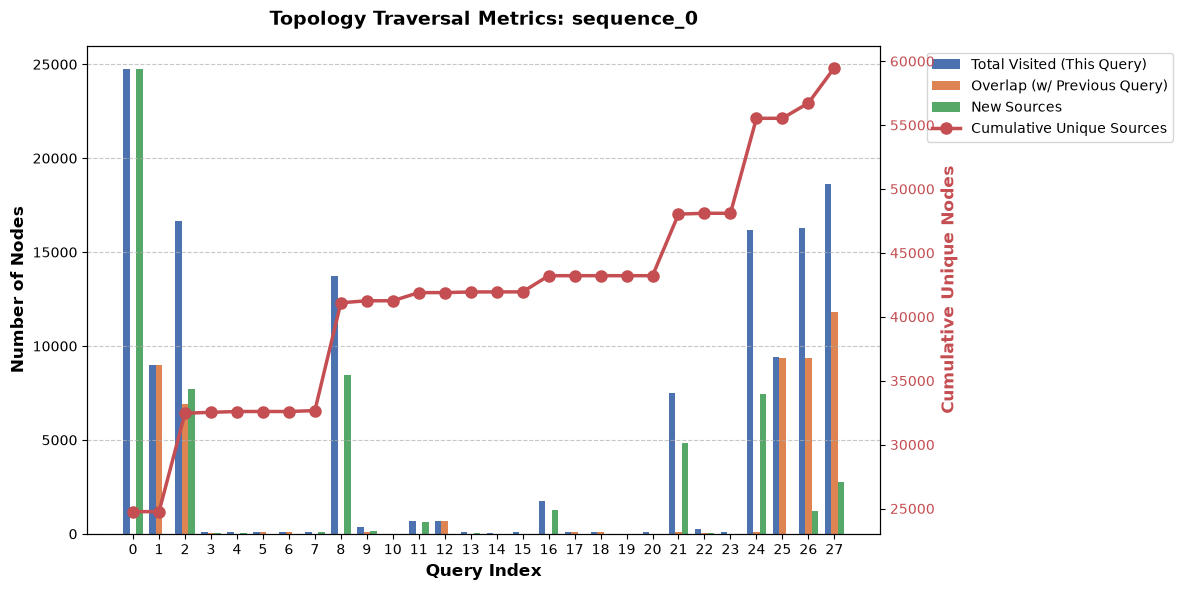

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sequence_metrics(df, sequence_name):
    """
    Generates a combo plot for a specific query sequence showing node traversal metrics.
    """
    # Filter data for the requested sequence
    seq_data = df[df["Sequence"] == sequence_name].copy()

    if seq_data.empty:
        print(f"No data found for sequence: {sequence_name}")
        return

    # Calculate cumulative unique sources for the line chart overlay
    seq_data["Cumulative Unique"] = seq_data["New Sources"].cumsum()

    x = seq_data["Query Index"]
    x_indexes = np.arange(len(x))
    bar_width = 0.25

    # Create the main figure and axis
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # 1. Plot Grouped Bars for per-query metrics
    ax1.bar(x_indexes - bar_width, seq_data["Visited Nodes"], width=bar_width,
            label="Total Visited (This Query)", color="#4C72B0")

    ax1.bar(x_indexes, seq_data["Sequential Overlap"], width=bar_width,
            label="Overlap (w/ Previous Query)", color="#DD8452")

    ax1.bar(x_indexes + bar_width, seq_data["New Sources"], width=bar_width,
            label="New Sources", color="#55A868")

    # Formatting primary axis
    ax1.set_xlabel("Query Index", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Number of Nodes", fontsize=12, fontweight="bold")
    ax1.set_xticks(x_indexes)
    ax1.set_xticklabels(x)
    ax1.tick_params(axis="y")
    ax1.grid(axis="y", linestyle="--", alpha=0.7)

    # 2. Create a secondary axis for the Cumulative Unique line chart
    ax2 = ax1.twinx()
    ax2.plot(x_indexes, seq_data["Cumulative Unique"], color="#C44E52",
             marker="o", linewidth=2.5, markersize=8, label="Cumulative Unique Sources")

    ax2.set_ylabel("Cumulative Unique Nodes", fontsize=12, fontweight="bold", color="#C44E52")
    ax2.tick_params(axis="y", labelcolor="#C44E52")

    # 3. Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", bbox_to_anchor=(1.05, 1))

    # Title and layout
    plt.title(f"Topology Traversal Metrics: {sequence_name}", fontsize=14, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

# Example Execution:
# Grab the first sequence name from your dataframe to plot
unique_sequences = df_metrics["Sequence"].unique()
plot_sequence_metrics(df_metrics, unique_sequences[4])